# Example of a State Space model on Synthetic Data

> Regression solves for parameters that best fit an equation to data, while state-space model find a process that defines how a variable changes from one step to the next.

- Makes use of the [notebook](https://github.com/pymc-devs/pymc-extras/blob/main/notebooks/Structural%20Timeseries%20Modeling.ipynb) for model structure
- First major use case was the Apollo missions. They had two types of sensors, both of which were slightly wrong. They needed a way to fuse the "Physics" (the equations of orbital mechanics) with "Observations" (the noisy radar blips).

**The State-Transition Equation (The Physics)**
This equation defines how the system evolves from one time step to the next. It represents the "Internal Process."
 $$\alpha_{t+1} = T_t \alpha_t + R_t \eta_t, \quad \eta_t \sim N(0, Q_t)$$
- $\alpha_t$: The State Vector. It holds your variables system components. (*note* some can be hidden, i.e not observable)
- $T_t$: The Transition Matrix. This is the process that moves the states forward (e.g., New Level = Old Level + Old Slope).
- $R_t$: The Selection Matrix. It maps which states are affected by random shocks and can change with time.
- $\eta_t$: Innovations. These are the "Shocks" that allow the system to drift.
- $Q_t$: The Process Covariance Matrix. It defines the size of the drift.
  
**The Observation Equation (The Measurement)**
This equation links the hidden states to the actual data.
$$y_t = Z_t \alpha_t + \epsilon_t, \quad \epsilon_t \sim N(0, H_t)$$
- $y_t$: The Observed Variable.
- $Z_t$: The Observation Matrix. Pulls the hidden states together to create the output.
- $\epsilon_t$: The Measurement Noise (or Observation Error).
- $H_t$: The Observation Covariance. This defines the "Daily Jitter"—the variance of the noise that doesn't represent a permanent change in the system.

## Synthetic Data Set

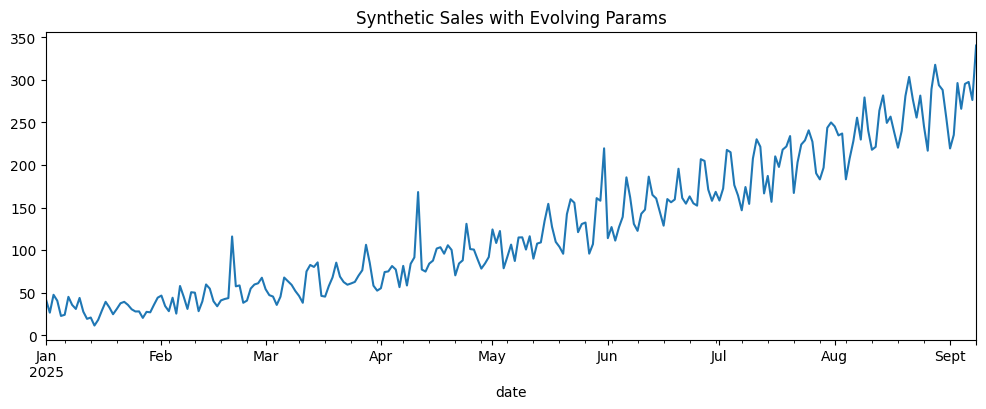

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 251
t = np.arange(n)

# growth
slope = 0.1 + (0.005 * t)
trend = np.cumsum(slope)

# seasonality
amplitude = 5 + (0.1 * t)
div = np.linspace(4, 8, n)
seasonality = amplitude * np.sin(
    2 * np.pi * t / 7
) 

#  Noise
noise = np.random.normal(0, 5, size=n)

# spend impact
spend = np.random.rand(n) * 20 + 20
initial_impact = 1
increase_rate = 0.005
beta_t = initial_impact * np.exp(increase_rate * t)

spend = np.random.rand(n) * 20 + 20
exo_impact = beta_t * spend

# events
t_event = np.zeros_like(t)
t_event[50::50] += 1
beta_event = 60
exo_event = beta_event * t_event

sales = trend + seasonality + noise + exo_impact + exo_event

dates = pd.date_range("2025-01-01", periods=n, freq="D")
df = pd.DataFrame(
    {"date": dates, "sales": sales, "spend": spend, "event": t_event}
).set_index("date")

df["sales"].plot(title="Synthetic Sales with Evolving Params", figsize=(12, 4))
plt.show()

## Data Components (What we want to find)

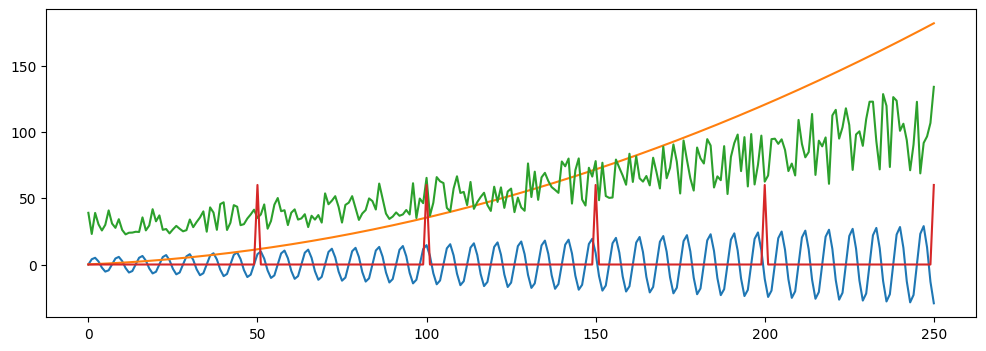

In [17]:
plt.figure(figsize=(12,4))
plt.plot(seasonality)
plt.plot(trend)
plt.plot(exo_impact)
plt.plot(exo_event)

## Create State-Space Model

In [18]:
import pymc_extras.statespace as pmss
from pymc_extras.statespace import structural as st

- Define what is time varying and what isn't.
- Find model coords and dimensions
- Define structural components

In [19]:
mod = st.LevelTrend(order=2, innovations_order=[0, 1])
mod += st.Regression(name="exog", state_names=["spend_impact"], innovations=True) 
mod += st.Regression(name="2_exog", state_names=["event_impact"], innovations=False) 
mod += st.FrequencySeasonality(7, n = 3, name="weekly")
mod += st.MeasurementError(name="obs")

ss_mod = mod.build(name="sales", mode="JAX")

dims = ss_mod.param_dims.values()
coords = ss_mod.coords


                                  Model Requirements                                   
                                                                                       
  Variable              Shape       Constraints                            Dimensions  
 ───────────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (2,)                                   ('state_level_trend',)  
  sigma_level_trend     (1,)        Positive                   ('shock_level_trend',)  
  beta_exog             (1,)                                          ('state_exog',)  
  sigma_beta_exog       (1,)        Positive                          ('state_exog',)  
  beta_2_exog           (1,)                                        ('state_2_exog',)  
  params_weekly         (6,)                                        ('state_weekly',)  
  sigma_weekly          ()          Positive                                     None  
  sigma_obs             ()          Positive                                     None  
  P0                    (10, 10)    Positive semi-definite     ('state', 'state_aux')  
                                                                                       
  data_exog             (None, 1)   pm.Data                    ('time', 'state_exog')  
  data_2_exog           (None, 1)   pm.Data                  ('time', 'state_2_exog')  
                                                                                       
These parameters should be assigned priors inside a PyMC model block before calling the
                            build_statespace_graph method.                             

### Test and train split

In [6]:
train = df.iloc[:-50]
test = df.iloc[-50:]

## Sample model

- Set up priors
  - "how much do I expect things to vary with time"
  - "What do I think the values are based on domain knowledge"
- Set up model data for exogenous variables
- Can use `nutpie` for faster cpu performance

<Axes: >

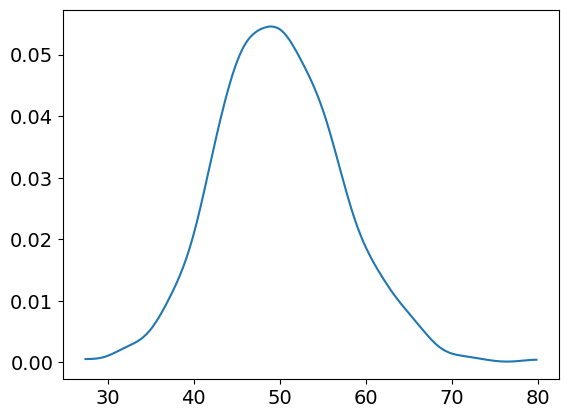

In [25]:
samples = pm.draw(pm.Gamma.dist(alpha=50, beta=1), draws=1000)
az.plot_dist(samples)

In [26]:
import pymc as pm
import pytensor.tensor as pt

with pm.Model(coords=coords) as model_1:
    P0_diag = pm.Gamma("P0_diag", alpha=50, beta=1)
    P0 = pm.Deterministic("P0", pt.eye(ss_mod.k_states) *P0_diag  , dims=('state', 'state_aux'))

    initial_level_trend = pm.Normal("initial_level_trend", dims=('state_level_trend',) )
    data_exo = pm.Data("data_exog", train[["spend"]].values, dims=["time", "state_exog"])
    data_2_exo = pm.Data("data_2_exog", train[["event"]].values.astype(float), dims=["time", "state_2_exog"])
    
    beta_regression = pm.HalfNormal("beta_exog", sigma=3, dims="state_exog")
    beta_2_regression = pm.HalfNormal("beta_2_exog", sigma=20, dims="state_2_exog")
    sigma_beta_exog = pm.Gamma("sigma_beta_exog", alpha=2, beta=1, dims=("state_exog",))
    
    annual_seasonal = pm.Normal("params_weekly", sigma=10, dims=("state_weekly",))

    sigma_level_trend = pm.Gamma("sigma_level_trend", alpha=2, beta=1, dims=('shock_level_trend',))
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=5)
    
    sigma_weekly_season = pm.Gamma("sigma_weekly", alpha=2, beta=1)

    ss_mod.build_statespace_graph(train["sales"], mode='JAX')
    idata = pm.sample(nuts_sampler="nutpie")


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.60,7
,2000,0,0.70,7
,2000,0,0.60,7
,2000,0,0.66,7


### View Initial Model Parameters

- These are *not* the final values of the model (as with regression)
- They define the starting distributions, and how things vary with time
  - Tight "sigma" values -> low time varying properties
  - Wide "sigma" values -> large time varying properties

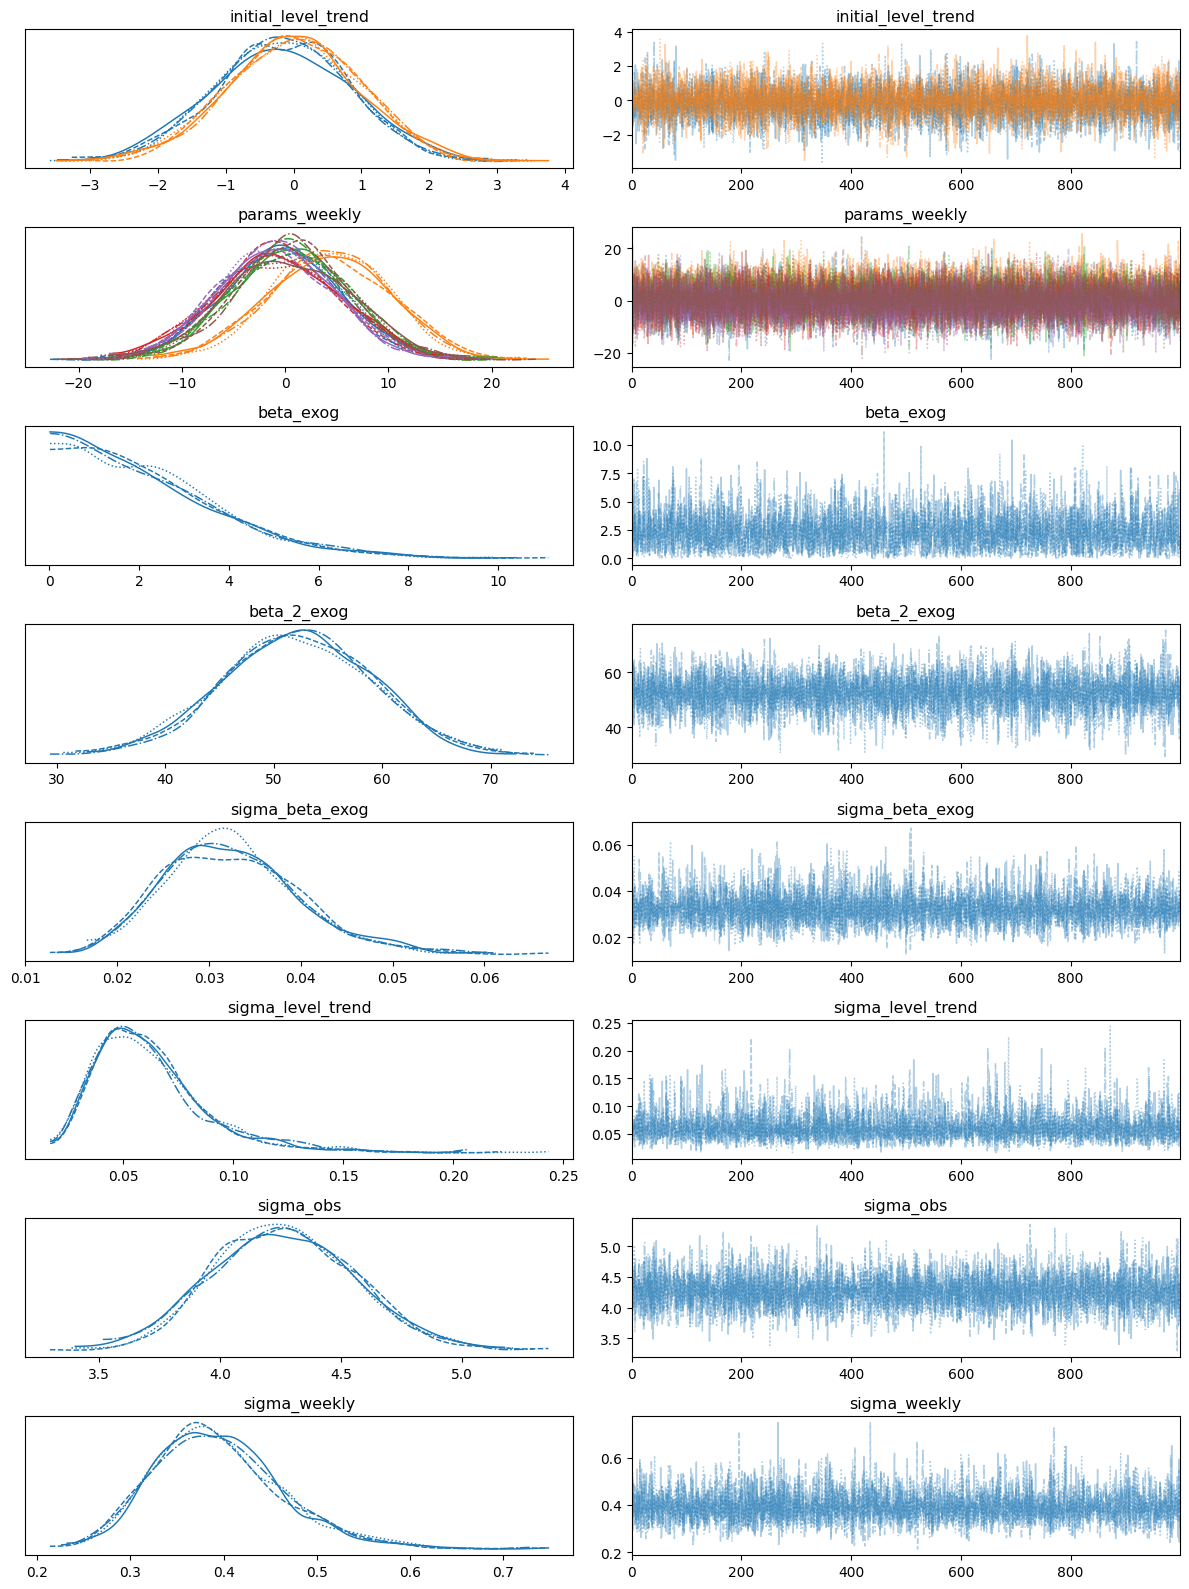

In [29]:
import arviz as az
ax = az.plot_trace(idata, var_names=["~P0", "~__"], filter_vars="like")
plt.tight_layout()


## Conditional Sampling and Components Extraction

- Smoothing conceptual answers the question:
  > "How much did my prediction for tomorrow ($t+1$) change once I actually saw the data for tomorrow? I should apply a portion of that change back to my estimate for today ($t$)."
- Typically state space model are "real time", but this runs the backwards to further remove noise

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x1B4E1932EA0>), RNG(<Generator(PCG64) at 0x1B4E1932DC0>), RNG(<Generator(PCG64) at 0x1B4E1932CE0>), RNG(<Generator(PCG64) at 0x1B4E1932C00>), RNG(<Generator(PCG64) at 0x1B4E19320A0>), RNG(<Generator(PCG64) at 0x1B4E2007A00>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Variables filtered_posterior_observed, predicted_posterior_observed, smoothed_posterior_observed do not contain all hidden states (their last dimension is not 10). They will not be present in the modified idata.


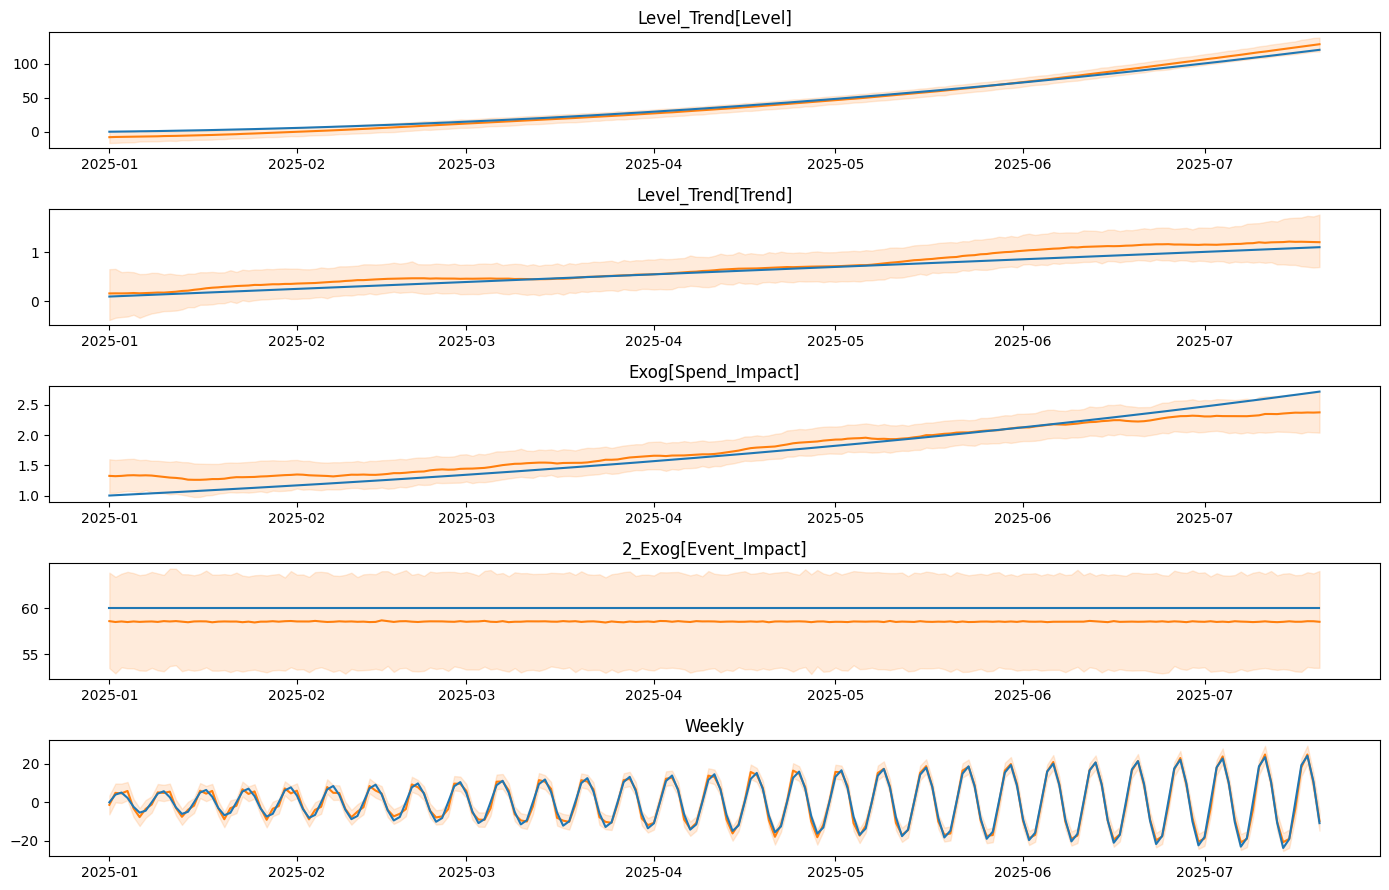

In [30]:
post_pred = ss_mod.sample_conditional_posterior(idata, mvn_method="cholesky")
component_idata = ss_mod.extract_components_from_idata(post_pred)
component_hdi = az.hdi(component_idata, hdi_prob=0.95)

fig, ax = plt.subplots(5, 1, figsize=(14, 9))

for axis, state in zip(fig.axes, component_idata.coords["state"].values):
    axis.plot(
        train.index,
        component_idata.stack(sample=["chain", "draw"])
        .smoothed_posterior.sel(state=state)
        .mean(dim="sample"),
        color="tab:orange",
    )
    axis.fill_between(
        train.index,
        *component_hdi.smoothed_posterior.sel(state=state).values.T,
        color="tab:orange",
        alpha=0.15,
    )
    axis.set_title(state.title())

ax[0].plot(train.index, trend[:-50])
ax[1].plot(train.index, slope[:-50])
ax[2].plot(train.index, beta_t[:-50])
ax[3].plot(train.index, beta_event * np.ones_like(beta_t[:-50]))
ax[4].plot(train.index, seasonality[:-50])

plt.tight_layout()

### View Impact of Spend 

Text(0.5, 1.0, 'Impact of Spend')

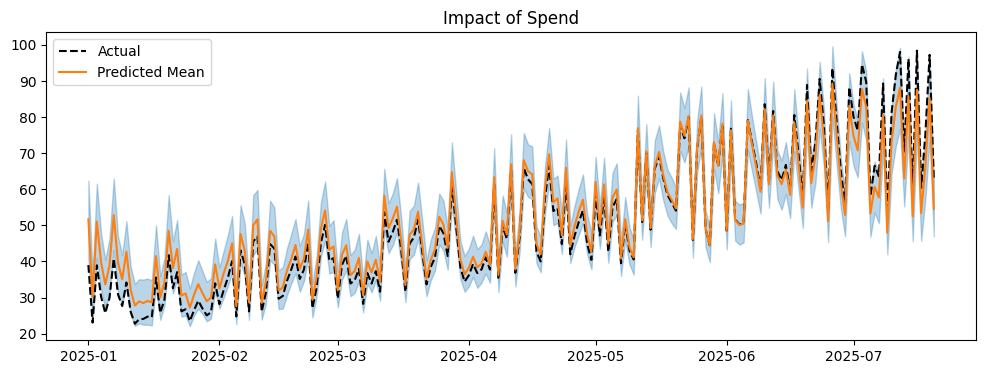

In [31]:
fig, ax = plt.subplots(1,1,figsize=(12,4))

ax.plot(train.index, exo_impact[:-50], 'k--', label = "Actual")

ax.plot(
    train.index,
    component_idata.stack(sample=["chain", "draw"])
    .smoothed_posterior.isel(state=2)
    .mean(dim="sample")
    * spend[:-50],
    color="tab:orange",
    label = "Predicted Mean"
)
ax.fill_between(
    train.index,
    *component_hdi.smoothed_posterior.isel(state=2).values.T * spend[:-50],
    color="tab:blue",
    alpha=0.3,
)
ax.legend()
ax.set_title("Impact of Spend")

### Impact of Events

Text(0.5, 1.0, 'Impact of Events')

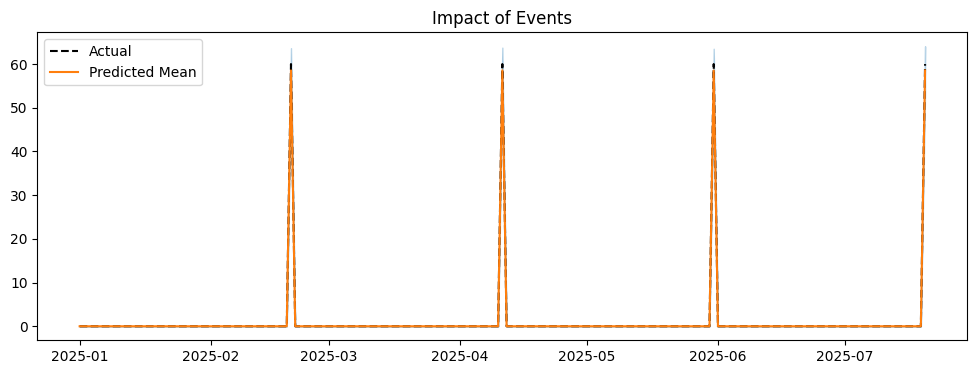

In [32]:
fig, ax = plt.subplots(1,1,figsize=(12,4))

ax.plot(train.index, exo_event[:-50], 'k--', label = "Actual")

ax.plot(
    train.index,
    component_idata.stack(sample=["chain", "draw"])
    .smoothed_posterior.isel(state=3)
    .mean(dim="sample")
    * t_event[:-50],
    color="tab:orange",
    label = "Predicted Mean"
)
ax.fill_between(
    train.index,
    *component_hdi.smoothed_posterior.isel(state=3).values.T * t_event[:-50],
    color="tab:blue",
    alpha=0.3,
)
ax.legend()
ax.set_title("Impact of Events")

## Forecast with Scenarios

In [33]:
scenario = {
    "data_exog": pd.DataFrame(spend[-50:], columns=["spend_impact"]),
    "data_2_exog": pd.DataFrame(t_event[-50:], columns=["event_impact"]),
}

forecast = ss_mod.forecast(
    idata,
    start=train.index[-1],
    periods=50,
    scenario=scenario,
)

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x1B45DF2C660>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
Sampling: [forecast_combined]


Output()

### Daily Prediction

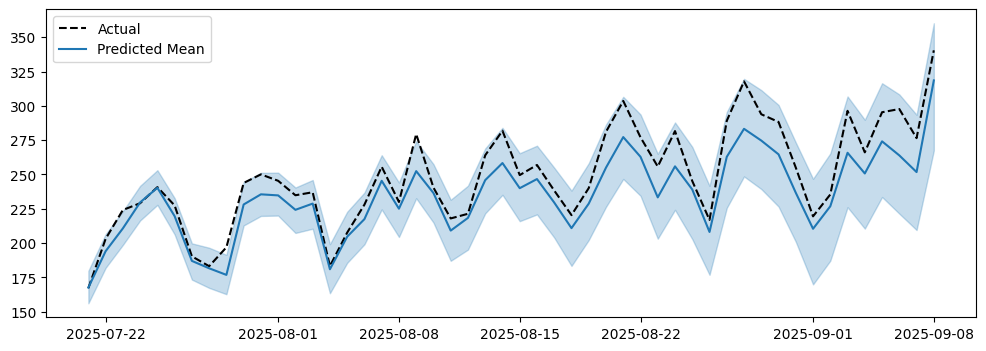

In [34]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(test.index, test.sales.values, "k--", label = "Actual")

forecast_time = forecast.coords["time"]
mu_forecast = forecast.forecast_observed.mean(dim=["chain", "draw"]).isel(
    observed_state=0
)
hdi_forecast = az.hdi(forecast.forecast_observed, hdi_prob=0.50).forecast_observed.isel(
    observed_state=0
)
hdi_forecast_95 = az.hdi(
    forecast.forecast_observed, hdi_prob=0.95
).forecast_observed.isel(observed_state=0)

ax.plot(forecast_time, mu_forecast, label = "Predicted Mean")
ax.fill_between(forecast_time, *hdi_forecast_95.values.T, alpha=0.25, color="tab:blue")

ax.legend()
plt.show()

### Cumlative Prediction

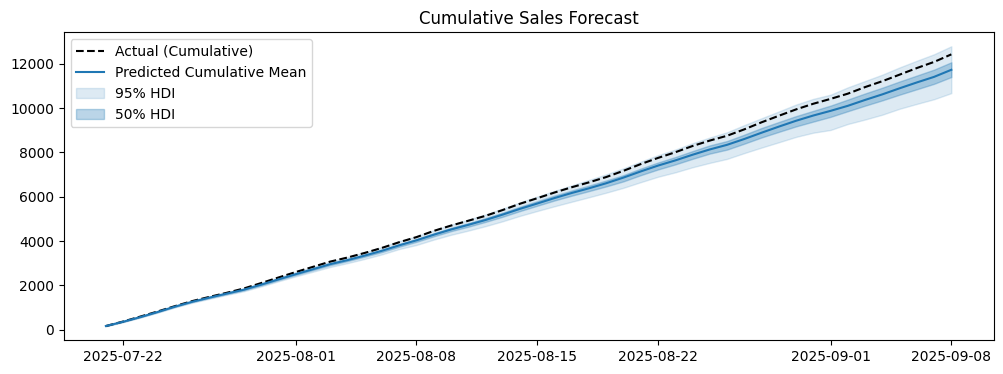

In [35]:
fig, ax = plt.subplots(figsize=(12, 4))

# 1. Cumulative Actuals
ax.plot(test.index, test.sales.values.cumsum(), "k--", label="Actual (Cumulative)")

# 2. Extract the raw posterior predictive samples
# Assuming 'time' is the dimension you want to sum over
post_pred = forecast.forecast_observed.isel(observed_state=0)
cum_post_pred = post_pred.cumsum(dim="time")

# 3. Calculate Cumulative Mean and HDIs
forecast_time = forecast.coords["time"]
mu_cum = cum_post_pred.mean(dim=["chain", "draw"])

hdi_50 = az.hdi(cum_post_pred, hdi_prob=0.50)
hdi_95 = az.hdi(cum_post_pred, hdi_prob=0.95)

# 4. Plotting
ax.plot(forecast_time, mu_cum, label="Predicted Cumulative Mean", color="tab:blue")

# 95% Interval
ax.fill_between(
    forecast_time, 
    hdi_95.forecast_observed.values[:, 0], hdi_95.forecast_observed.values[:, 1], 
    alpha=0.15, color="tab:blue", label="95% HDI"
)

# 50% Interval (Optional, but helps visualize the core trajectory)
ax.fill_between(
    forecast_time, 
    hdi_50.forecast_observed.values[:, 0], hdi_50.forecast_observed.values[:, 1], 
    alpha=0.3, color="tab:blue", label="50% HDI"
)

ax.set_title("Cumulative Sales Forecast")
ax.legend()
plt.show()

# Test classes

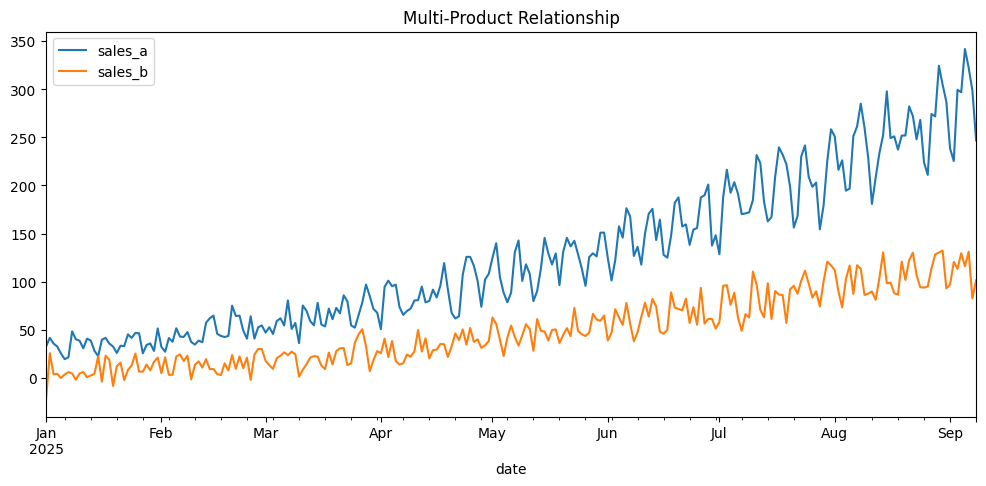

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 251
t = np.arange(n)

# Base Growth and Seasonality (Shared Logic)
slope = 0.1 + (0.005 * t)
trend = np.cumsum(slope)
seasonality = (5 + 0.1 * t) * np.sin(2 * np.pi * t / 7)

# Product A: Original Logic
spend_a = np.random.rand(n) * 20 + 20
beta_a = 1 * np.exp(0.005 * t)
sales_a = trend + seasonality + (beta_a * spend_a) + np.random.normal(0, 5, n)

# Product B: Introducing the Relationship
# Scenario: Product B is a 'Halo' product or a competitor. 
# We model Product B as having a baseline + a lagged influence from Product A.
relationship_strength = -0.3 # Negative for Cannibalization, Positive for Halo
lag = 1
sales_a_lagged = np.roll(sales_a, lag)
sales_a_lagged[:lag] = np.mean(sales_a) # Fill initial lag

# Product B Specifics
spend_b = np.random.rand(n) * 15 + 10
sales_b = (0.8 * trend) + (0.6 *  seasonality) + (relationship_strength * sales_a_lagged) + (beta_a * spend_b) + np.random.normal(0, 5, n)

# Create DataFrame
dates = pd.date_range("2025-01-01", periods=n, freq="D")
df = pd.DataFrame({
    "date": dates, 
    "sales_a": sales_a, 
    "sales_b": sales_b, 
    "spend_a": spend_a,
    "spend_b": spend_b
}).set_index("date")

df[["sales_a", "sales_b"]].plot(title="Multi-Product Relationship", figsize=(12, 5))
plt.show()

In [2]:
train = df.iloc[:-50]
test = df.iloc[-50:]

In [3]:
from optistock.forecasting.state_space import UnivariateSSM

model = UnivariateSSM(train, target_col="sales_a", exog={"spend_a": True})

model.build_model(2, trend_innovations_order=[0,1], seasonal_period=7)

model.fit()

                                   Model Requirements                                   
                                                                                        
  Variable              Shape       Constraints                             Dimensions  
 ────────────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (2,)                                    ('state_level_trend',)  
  sigma_level_trend     (1,)        Positive                    ('shock_level_trend',)  
  beta_spend_a          (1,)                                        ('state_spend_a',)  
  sigma_beta_spend_a    (1,)        Positive                        ('state_spend_a',)  
  params_seasonal       (6,)                                       ('state_seasonal',)  
  sigma_seasonal        ()          Positive                                      None  
  sigma_obs             ()          Positive                                      None  
  P0                    (9, 9)      Positive semi-definite      ('state', 'state_aux')  
                                                                                        
  data_spend_a          (None, 1)   pm.Data                  ('time', 'state_spend_a')  
                                                                                        
These parameters should be assigned priors inside a PyMC model block before calling the 
                             build_statespace_graph method.                             

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:92: UserWarning: No frequency was specific on the data's DateTimeIndex.
  warnings.warn(NO_FREQ_INFO_WARNING)
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.62,7
,2000,0,0.58,7
,2000,0,0.62,7
,2000,0,0.71,7


In [20]:
forecast = model.forecast(periods=50, scenario={"data_spend_a": test["spend_a"][:50]})

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x2B5D7EBC820>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
Sampling: [forecast_combined]


Output()

In [5]:
model.smooth_and_filter()

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x2B56D67D9A0>), RNG(<Generator(PCG64) at 0x2B56D67D000>), RNG(<Generator(PCG64) at 0x2B56D67DA80>), RNG(<Generator(PCG64) at 0x2B56D67DC40>), RNG(<Generator(PCG64) at 0x2B56D67C4A0>), RNG(<Generator(PCG64) at 0x2B51CC0F060>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Variables filtered_posterior_observed, predicted_posterior_observed, smoothed_posterior_observed do not contain all hidden states (their last dimension is not 9). They will not be present in the modified idata.


(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'sales_a — In-sample Smoothed Posterior'}>)

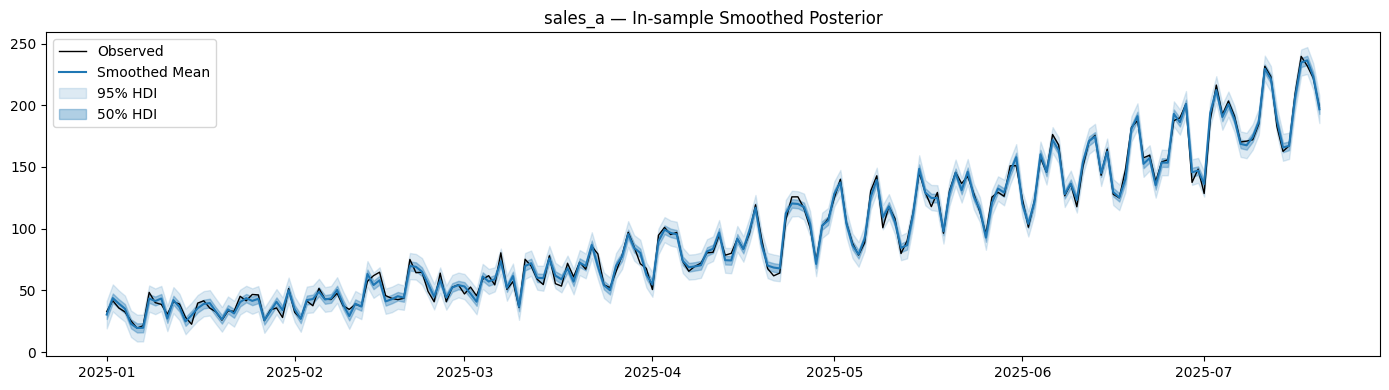

In [9]:
model.plot_fit()

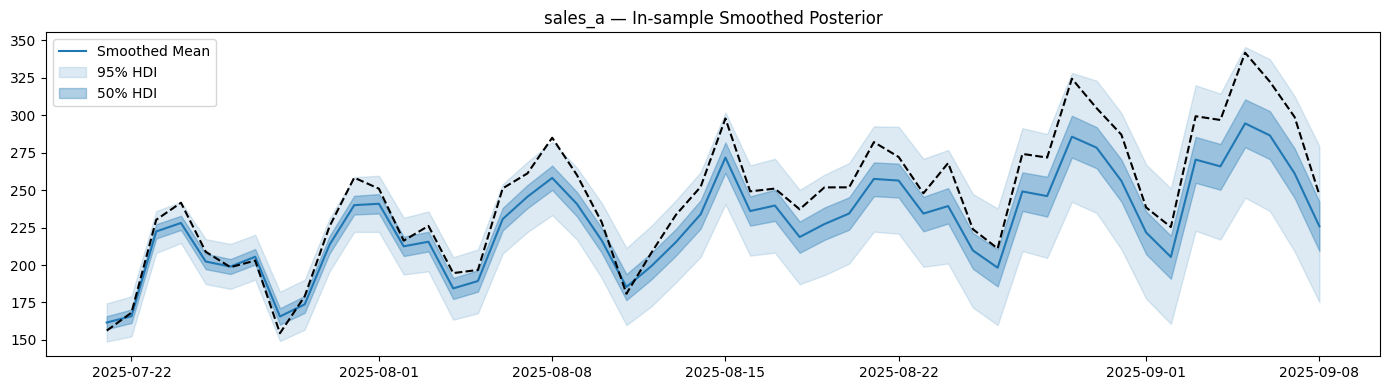

In [21]:
fig, ax = model.plot_forecast()
ax.plot(test.index, test["sales_a"], "k--", label="Actual")

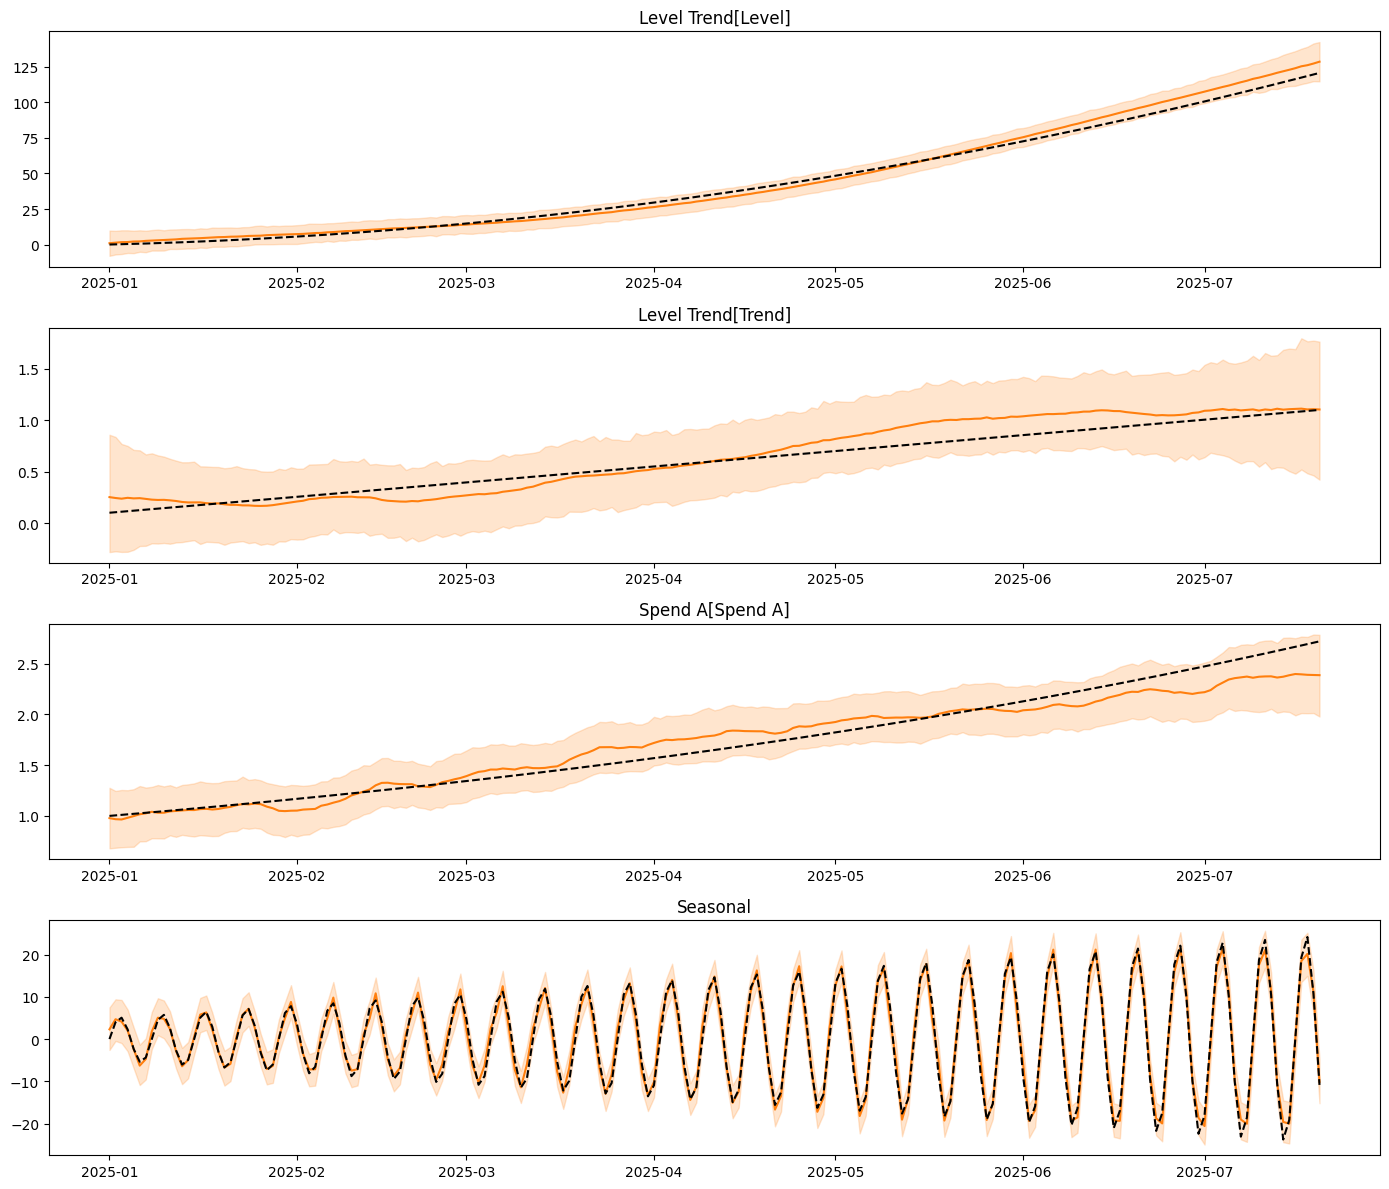

In [11]:
fig, ax = model.plot_components()

ax[0].plot(train.index, trend[:-50], 'k--', label = "Actual Trend")
ax[1].plot(train.index, slope[:-50], 'k--', label = "Actual Slope")
ax[2].plot(train.index, beta_a[:-50], 'k--', label = "Actual Beta")
ax[3].plot(train.index, seasonality[:-50], 'k--', label = "Actual Seasonality")

In [ ]:
total = model.get_demand_distribution("2025-08-01", "2025-08-30")

UFuncTypeError: ufunc 'greater_equal' did not contain a loop with signature matching types (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

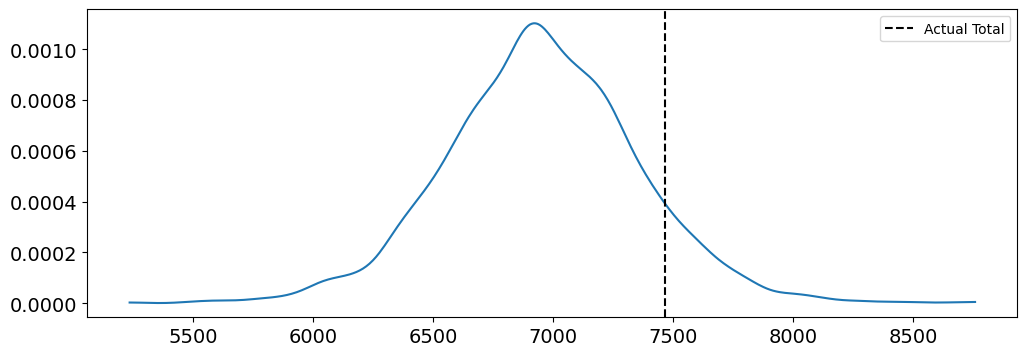

In [27]:
import arviz as az
fig, ax = plt.subplots(figsize=(12, 4))
az.plot_dist(total.stack(sample=["chain", "draw"]), ax=ax)
actual_total = test["sales_a"].loc[start_date:end_date].sum()
ax.axvline(actual_total, color="k", linestyle="--", label="Actual Total")
ax.legend()

# Inventory Optimisation with State Space Forecaster

The fitted `UnivariateSSM` is plugged directly into a newsvendor-style `ForecastSolver`.  
Demand samples come from the posterior predictive forecast over a **30-day planning horizon** (2025-07-21 → 2025-08-19).

Three risk objectives are compared:

| Objective | Description |
|-----------|-------------|
| **SAA** | Maximise expected profit |
| **CVaR** | Hedge against worst 10 % of scenarios (λ = 0.70) |
| **Utility** | Exponential utility with risk tolerance ρ = 500 |

The vertical black line in each distribution panel shows the **true profit** realised against actual test-period sales.

In [14]:
from optistock.items import Item

# Planning horizon — within the 50-day forecast window
plan_start = "2025-07-21"
plan_end   = "2025-08-19"   # 30 days

item_a = Item(
    name="sales_a",
    cost_price=10.0,
    selling_price=15.0,
    salvage_value=2.0,
)
print(f"Critical Fractile : {item_a.critical_fractile:.3f}")
print(f"Underage Cost     : {item_a.underage_cost:.2f}")
print(f"Overage Cost      : {item_a.overage_cost:.2f}")

Critical Fractile : 0.385
Underage Cost     : 5.00
Overage Cost      : 8.00


In [15]:
from optistock.solvers import ForecastSolver

# Three solvers — same forecaster, different risk objectives
solver_saa = ForecastSolver(
    problems=(item_a, model),
    objective="SAA",
)
solver_cvar = ForecastSolver(
    problems=(item_a, model),
    objective="CVaR",
    cvar_alpha=0.10,
    cvar_lambda=0.70,   # 70 % weight on the tail
)
solver_utility = ForecastSolver(
    problems=(item_a, model),
    objective="Utility",
    risk_aversion=500.0,  # same units as profit
)

q_saa     = solver_saa.solve(plan_start, plan_end)
q_cvar    = solver_cvar.solve(plan_start, plan_end)
q_utility = solver_utility.solve(plan_start, plan_end)

print("Optimal order quantities (30-day horizon):")
print(f"  SAA:              {q_saa['sales_a']}")
print(f"  CVaR (λ=0.70):   {q_cvar['sales_a']}")
print(f"  Utility (ρ=500): {q_utility['sales_a']}")

Optimal order quantities (30-day horizon):
  SAA:              6377
  CVaR (λ=0.70):   6000
  Utility (ρ=500): 5634


In [16]:
for name, solver in [("SAA", solver_saa), ("CVaR", solver_cvar), ("Utility", solver_utility)]:
    s = solver.summary()
    print(f"── {name} " + "─" * (42 - len(name)))
    print(f"  Allocation      : {s['allocation']}")
    print(f"  E[profit]       : {s['expected_profit']:.2f}")
    print(f"  Profit Std      : {s['profit_std']:.2f}")
    print(f"  CVaR 10%        : {s['cvar_10pct']:.2f}")
    print(f"  Service Level   : {s['service_level']:.1%}")
    if "certainty_equivalent" in s:
        print(f"  Certainty Equiv.: {s['certainty_equivalent']:.2f}")
        print(f"  Risk Premium    : {s['risk_premium']:.2f}")
    print()

── SAA ───────────────────────────────────────
  Allocation      : {'sales_a': 6377}
  E[profit]       : 30913.34
  Profit Std      : 1806.41
  CVaR 10%        : 26438.66
  Service Level   : 38.6%

── CVaR ──────────────────────────────────────
  Allocation      : {'sales_a': 6000}
  E[profit]       : 29908.35
  Profit Std      : 551.28
  CVaR 10%        : 29083.54
  Service Level   : 5.3%

── Utility ───────────────────────────────────
  Allocation      : {'sales_a': 5634}
  E[profit]       : 28163.75
  Profit Std      : 117.28
  CVaR 10%        : 28107.49
  Service Level   : 0.4%
  Certainty Equiv.: 27928.06
  Risk Premium    : 235.69



In [17]:
actual_demand = float(test["sales_a"].loc[plan_start:plan_end].sum())

def realised_profit(quantity: int, demand: float, item) -> float:
    sales    = min(quantity, demand)
    leftover = max(0, quantity - demand)
    return sales * item.selling_price + leftover * item.salvage_value - quantity * item.cost_price

tp_saa     = realised_profit(q_saa["sales_a"],     actual_demand, item_a)
tp_cvar    = realised_profit(q_cvar["sales_a"],    actual_demand, item_a)
tp_utility = realised_profit(q_utility["sales_a"], actual_demand, item_a)

print(f"Actual demand (30 days) : {actual_demand:.1f}")
print(f"Realised profit  SAA    : {tp_saa:.2f}")
print(f"Realised profit  CVaR   : {tp_cvar:.2f}")
print(f"Realised profit  Utility: {tp_utility:.2f}")

Actual demand (30 days) : 6756.6
Realised profit  SAA    : 31885.00
Realised profit  CVaR   : 30000.00
Realised profit  Utility: 28170.00


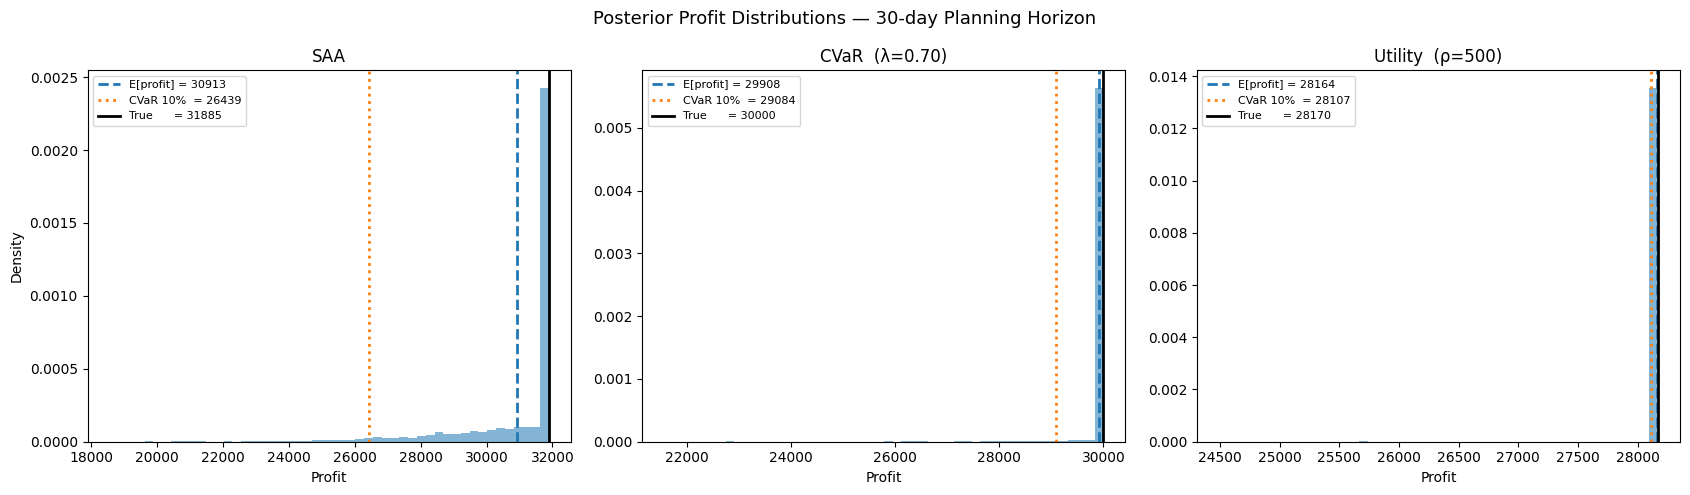

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

configs = [
    ("SAA",               solver_saa,     q_saa,     tp_saa),
    ("CVaR  (λ=0.70)",   solver_cvar,    q_cvar,    tp_cvar),
    ("Utility  (ρ=500)",  solver_utility, q_utility, tp_utility),
]

for ax, (label, solver, q, true_profit) in zip(axes, configs):
    q_arr   = np.array([q[item_a.name]], dtype=float)
    profits = solver._portfolio_profits(q_arr)
    ep      = float(profits.mean())
    n_t     = max(1, int(np.ceil(solver.cvar_alpha * len(profits))))
    cvar    = float(np.mean(np.sort(profits)[:n_t]))

    ax.hist(profits, bins=50, color="tab:blue", alpha=0.55, density=True)
    ax.axvline(ep,          color="tab:blue",   lw=2, ls="--", label=f"E[profit] = {ep:.0f}")
    ax.axvline(cvar,        color="tab:orange", lw=2, ls=":",  label=f"CVaR 10%  = {cvar:.0f}")
    ax.axvline(true_profit, color="black",      lw=2, ls="-",  label=f"True      = {true_profit:.0f}")
    ax.set_title(label)
    ax.set_xlabel("Profit")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Density")
fig.suptitle("Posterior Profit Distributions — 30-day Planning Horizon", fontsize=13)
fig.tight_layout()
plt.show()